# Lab 5 Data Processing Jupyter Notebook
Caroline & Bekah

In [28]:
# Import the Necessary Libraries

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from scipy.signal import welch # We'll need this for power spectral density estimation eventually

# Allow for interactive plotting in Jupyter notebooks, comment out the line to turn this off. 
# The % sign is a Jupyter magic command that enables the use of widgets in the notebook.
# This requires installing the ipympl package, so if you get an error on this line, 
# you may need to install it first by running: pip install ipympl

%matplotlib widget 

# For interactive data point selection in plots, this library is useful.
import mplcursors 

# Add this line of code to each plot if you want cursors: 
# mplcursors.cursor(hover=False, multiple=True)  # Enable interactive cursor for data point selection, right-click to remove cursor

# Use this command to set the default font size for your plots.
sns.set_context("notebook")
# Options from smallest to largest: "paper", "notebook", "talk", "poster"

Remember to use both Markdown and Code cells to import and plot your data. Refer back to the Tutorial if you need example code.

# Importing & Pre-Processing Heater Data

In [29]:
# import the dataset
myData = pd.read_csv("finaladjustedheater.csv")

# convert time from ms to minutes
# myData['Time (min)'] = myData['Time (ms)'] / 60000

# convert time from ms to seconds
myData['Time (s)'] = myData['Time (ms)'] / 1000

# smoothing function to improve quality for temperature, power, and current data
myData['Smoothed Temperature'] = myData[' Temperature (C)'].rolling(window=5).mean()
myData['Smoothed Current'] = myData[' Current (mA)'].rolling(window=5).mean()
myData['Smoothed Power'] = myData[' Power (mW)'].rolling(window=5).mean()

# Temperature Plot
Block over the course of the experiment

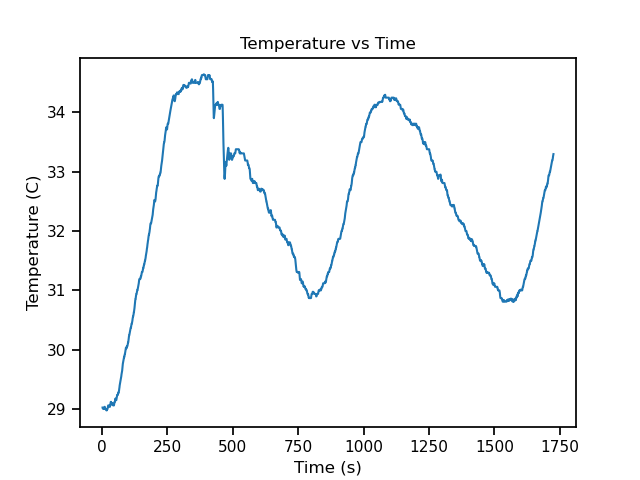

In [30]:
plt.figure()  # Create a new figure
sns.lineplot(x="Time (s)", y="Smoothed Temperature", data=myData)
plt.title("Temperature vs Time")
plt.xlabel("Time (s)")
plt.ylabel("Temperature (C)")

mplcursors.cursor(hover=False)  # Enable interactive cursor for data point selection

# Click anywhere on your data to add a cursor
# Right-click to remove a cursor

plt.show()

# Current Plot
Current supplied to heater throughout the experiment

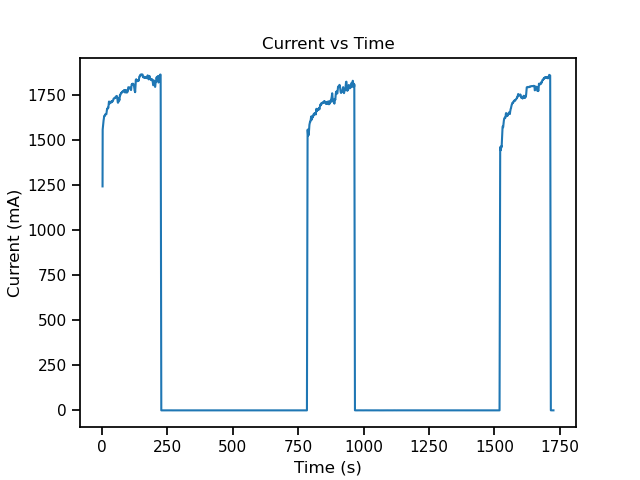

In [31]:
plt.figure()  # Create a new figure
sns.lineplot(x="Time (s)", y="Smoothed Current", data=myData)
plt.title("Current vs Time")
plt.xlabel("Time (s)")
plt.ylabel("Current (mA)")

mplcursors.cursor(hover=False)  # Enable interactive cursor for data point selection

# Click anywhere on your data to add a cursor
# Right-click to remove a cursor

plt.show()

# Heater Power & Energy Over Time Plot

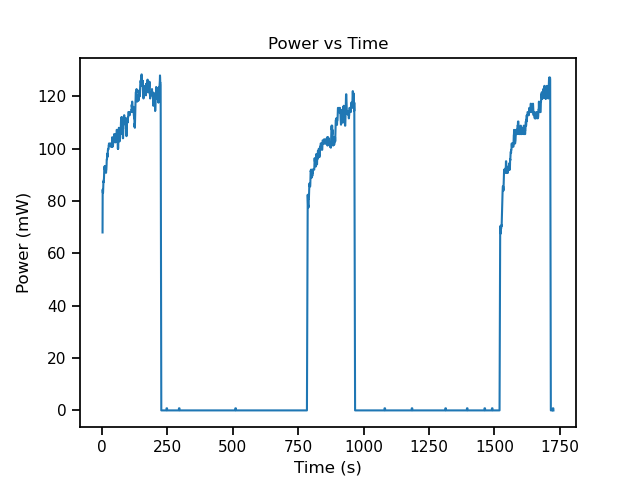

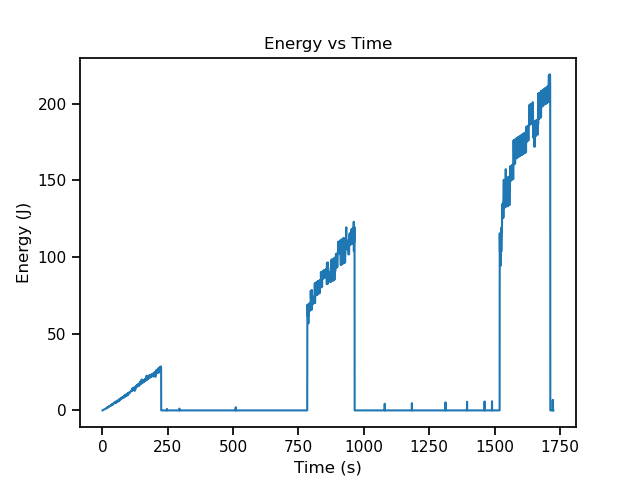

In [32]:
plt.figure()  # Create a new figure
sns.lineplot(x="Time (s)", y="Smoothed Power", data=myData)
plt.title("Power vs Time")
plt.xlabel("Time (s)")
plt.ylabel("Power (mW)")

mplcursors.cursor(hover=False)  # Enable interactive cursor for data point selection

# Click anywhere on your data to add a cursor
# Right-click to remove a cursor

plt.show()

# calculate energy
myData['Energy (J)'] = (myData[' Power (mW)']/1000) * myData['Time (s)']  # Convert mW to W for energy calculation

plt.figure()  # Create a new figure
sns.lineplot(x="Time (s)", y="Energy (J)", data=myData)
plt.title("Energy vs Time")
plt.xlabel("Time (s)")
plt.ylabel("Energy (J)")

mplcursors.cursor(hover=False)  # Enable interactive cursor for data point selection

# Click anywhere on your data to add a cursor
# Right-click to remove a cursor

plt.show()

# Efficiency Calculations

In [33]:
# define variables
m = 63.5 # mass of the block in grams
c = 0.9 # specific heat capacity of the block in J/g°C for aluminum shell

η = (Useful Energy Delivered/Energy Input)

η = mcΔT/ ((Vheater iheater) ∗ Time)

1. What is the efficiency of heating the block from room temperature to the set point of 32℃? 

In [34]:
t_0 = myData[' Temperature (C)'][0]  # Initial temperature (assumed to be room temperature)

# find first time temp reaches 32
t_32 = None
for i in range(len(myData)):
    if myData[' Temperature (C)'][i] >= 32:
        t_32 = myData['Time (s)'][i]
        break

heatup = myData[myData[' Temperature (C)'] <= t_32] # slice the data for just the heatup phase
avg_power = heatup[' Power (mW)'].mean() / 1000  # Convert mW to W for power calculation
t_29_32 = 32 - 29
delta_t = (t_32 - t_0)
n = (m*c*t_29_32) / (delta_t * avg_power) # efficiency calculation
print(f"Efficiency of heating the block from {t_0}℃ to 32℃: {n:.2f}")

Efficiency of heating the block from 29.0℃ to 32℃: 30.14


2. What is the efficiency of heating the block from 31℃ to 33℃ (e.g. where the system will operate most of the time, during the hysteresis loop)? 

In [35]:
# find first time temp reaches 31 (heater turns on)
t_31 = None
for i in range(len(myData)):
    if myData[' Temperature (C)'][i] >= 31:
        t_31 = myData['Time (ms)'][i]
        break

# find first time temp crosses 33 (heater turns off)
t_33 = None
for i in range(len(myData)):
    if myData[' Temperature (C)'][i] >= 33:
        t_33 = myData['Time (ms)'][i]
        break

hysteresis_loop = myData[(myData['Time (ms)'] >= t_31) & (myData['Time (ms)'] <= t_33)] # slice the data for just the hysteresis loop phase
avg_power = hysteresis_loop[' Power (mW)'].mean() / 1000  # Convert mW to W for power calculation
t_31_33 = 33 - 31
delta_t = (t_33 - t_31)
n = (m*c*t_31_33) / (delta_t * avg_power) # efficiency calculation
print(f"Efficiency of heating the block from 31℃ to 33℃: {n:.2f}")

Efficiency of heating the block from 31℃ to 33℃: 0.01


Qout = mCΔT/ Time

3. What is the average rate of heat loss for the block when the heater turns off at 33℃ until it turns back on at 31℃ ? 

In [36]:
# find first time temp crosses 33 (heater turns off)
t_33 = None
for i in range(len(myData)):
    if myData[' Temperature (C)'][i] >= 33:
        t_33 = myData['Time (ms)'][i]
        break

# find first time temp drops to 31 after t_33 (heater turns back on)
t_31 = None
for i in range(len(myData)):
    if myData[' Temperature (C)'][i] <= 31 and myData['Time (ms)'][i] > t_33:
        t_31 = myData['Time (ms)'][i]
        break

t_33_31 = 33 - 31
delta_t = (t_31 - t_33)
Q_out = (m*c*t_33_31)/ (delta_t/1000)  # Convert ms to seconds for rate calculation
print(f"Average rate of heat loss from 33℃ to 31℃ : {Q_out:.2f} J/s")

Average rate of heat loss from 33℃ to 31℃ : 0.21 J/s


4. Once the block reaches 32 ℃, how much energy is required to keep the block at constant temperature for 15 minutes?